In [28]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import find_peaks
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [29]:
HE_SHEET = "he test.xlsx"

df = pd.read_excel(HE_SHEET)
df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

# Sort by 'nm' to ensure correct neighbor comparison and plotting order
df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())

DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm  Unnamed: 3    Unnamed: 4  Unnamed: 5  \
0        2178   247.148  589.03701         NaN  max grey val         NaN   
1        2179   246.463  587.91075         NaN       247.148         NaN   
2        2180   243.830  586.78449         NaN           NaN         NaN   
3        2181   241.833  585.65823         NaN  min grey val         NaN   
4        2177   240.733  590.16327         NaN        16.674         NaN   

   Unnamed: 6 Unnamed: 7  
0  3042.03129   -1.12626  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN    he_3584  


In [30]:
y_title = 'Intensity'
x_title = 'Wavelength (nm)'
fig_size = (15,6)
prominence = 0.12
min_bright = 0.1
min_alpha = 0.1
gamma_factor = 0.8
bar_width = 1
smoothing_window = 5    # Increase this value to control the degree of smoothing
base_sigma_nm = 0.5 # Base width of the Gaussian (for low intensity peaks)
max_sigma_multiplier = 4.0 # How much wider the highest intensity peaks can be
x_min = 400
x_max = 750
mode = 'dark'
reverse_x = True
show_grid = True
plot_type = None

df_filtered['Smoothed_int'] = df_filtered['Grey Val'].rolling(window=smoothing_window, center=True).mean().fillna(df_filtered['Grey Val'])

if plot_type == 'Smoothed':
    min_int = df_filtered['Smoothed_int'].min
    max_int = df_filtered['Smoothed_int'].max
else:
    min_int = df_filtered['Grey Val'].min()
    max_int = df_filtered['Grey Val'].max()

int_range = max_int - min_int

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    if plot_type == 'Smoothed':
        df_filtered['Normalized_int'] = (df_filtered['Smoothed_int'] - min_int) / int_range
    else:
        df_filtered['Normalized_int'] = (df_filtered['Grey Val'] - min_int) / int_range

In [31]:
def rgb(wavelength, gamma=0.8):

    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif wavelength >= 440 and wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = (1.0) ** gamma
    elif wavelength >= 490 and wavelength <= 510:
        R = 0.0
        G = (1.0) ** gamma
        B = ((-(wavelength - 510) / (510 - 490))) ** gamma
    elif wavelength >= 510 and wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = (1.0) ** gamma
        B = 0.0
    elif wavelength >= 580 and wavelength <= 645:
        R = (1.0) ** gamma
        G = ((-(wavelength - 645) / (645 - 580))) ** gamma
        B = 0.0
    elif wavelength >= 645 and wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    return (R, G, B)

In [32]:
def axis_labels():
    ax = plt.gca()

    if mode == 'dark':
        fig_bg = 'black'
        text = 'white'
        plt.gcf().set_facecolor('black')
        if show_grid is True:
            plt.grid(show_grid, color='darkgrey', linestyle=':', linewidth=0.5)
    else:
        fig_bg = 'white'
        text = 'black'
        if show_grid is True:
            plt.grid(show_grid)
    
    if reverse_x is True:
        plt.xlim(x_max, x_min)
    else:
        plt.xlim(x_min, x_max)

    ax.set_facecolor(fig_bg)
    plt.xlabel(x_title, color=text)
    plt.ylabel(y_title, color=text)
    plt.xticks(color=text)
    plt.yticks(color=text)

In [33]:
def dynamic_prominence(prominence, int_range):
    dyn_prom = prominence * int_range
    return dyn_prom

In [34]:
def final_alpha(alpha_min, alpha_factor):
    final_alpha = alpha_min + (1 - alpha_min) * alpha_factor
    return final_alpha

In [35]:
def final_int_scale(int_factor):
    final_intensity_scale = min_bright + (1 - min_bright) * int_factor
    return final_intensity_scale

In [36]:
def colored_rgb(base_rgb, final_intensity_scale):
    colored_rgb = (base_rgb[0] * final_intensity_scale,
                   base_rgb[1] * final_intensity_scale,
                   base_rgb[2] * final_intensity_scale)
    return colored_rgb

this one doesn't account for intensity in the colour vibrancy like the other ones do

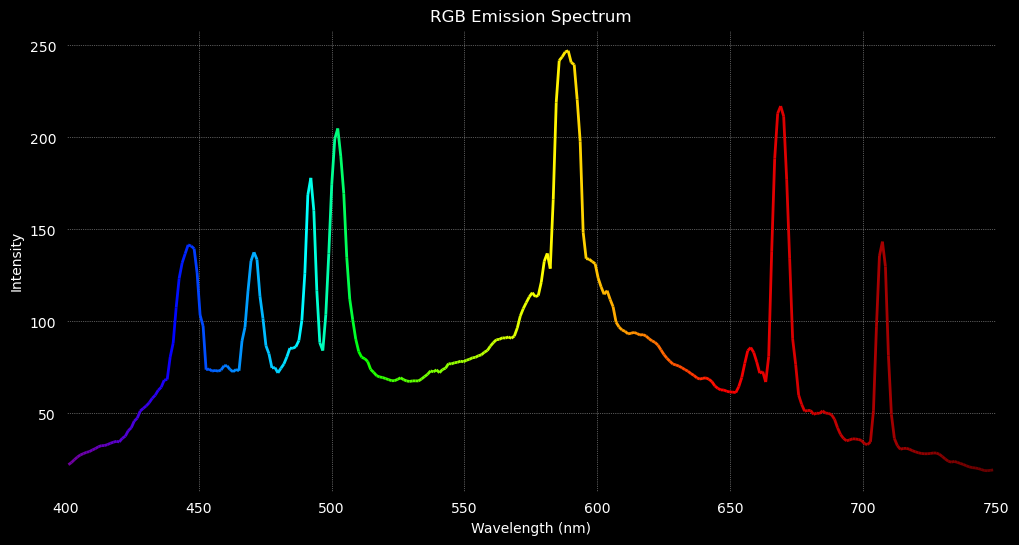

In [37]:
mode = 'dark'
reverse_x = False

# Apply the function to the 'nm' column to get RGB colors for each data point
colors = [rgb(nm) for nm in df_filtered['nm']]

# Prepare data for LineCollection
x = df_filtered['nm'].values
y = df_filtered['Grey Val'].values

# Create segments for LineCollection
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create a LineCollection with the calculated colors
lc = LineCollection(segments, colors=colors, linewidth=2)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
ax.add_collection(lc)
ax.autoscale()

axis_labels()

ax.set_title('RGB Emission Spectrum', color='white')
plt.show()

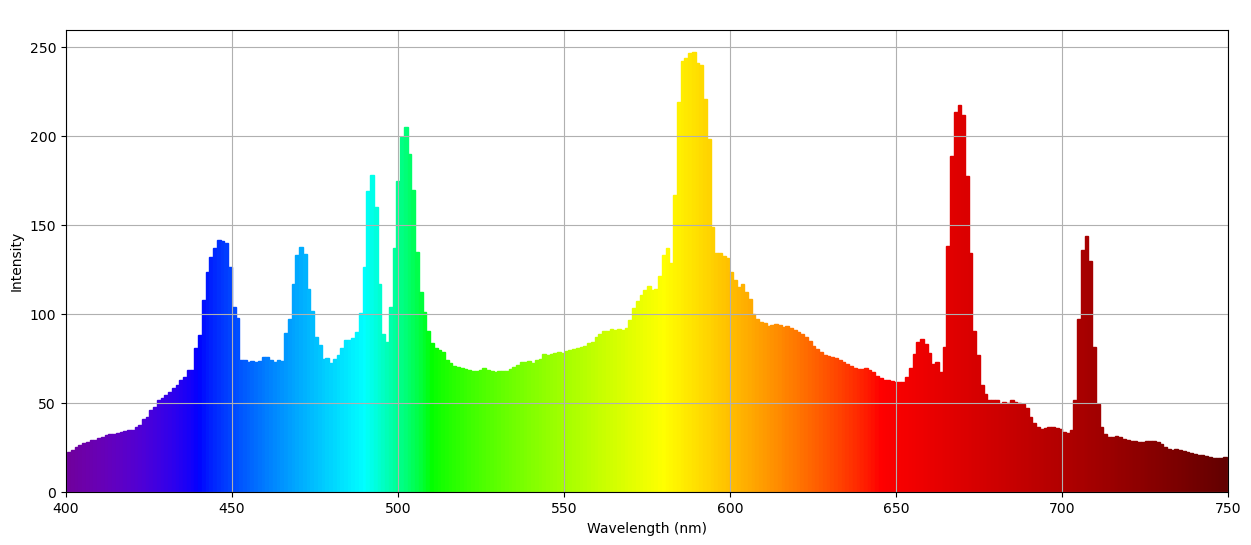

In [38]:
# Assuming df_filtered and colors (from rgb) are available from previous cells
mode = 'light'
reverse_x = False

# Create a bar chart with colors corresponding to the wavelength
plt.figure(figsize=(15, 6))
# Use a small width for the bars to make it look continuous
bar_width = np.diff(x).mean() if len(x) > 1 else 1

for i in range(len(x)):
    plt.bar(x[i], y[i], color=colors[i], width=bar_width, edgecolor=colors[i])

axis_labels()
plt.title('RGB Emission Spectrum (Bar Chart)', color='white')
plt.show()

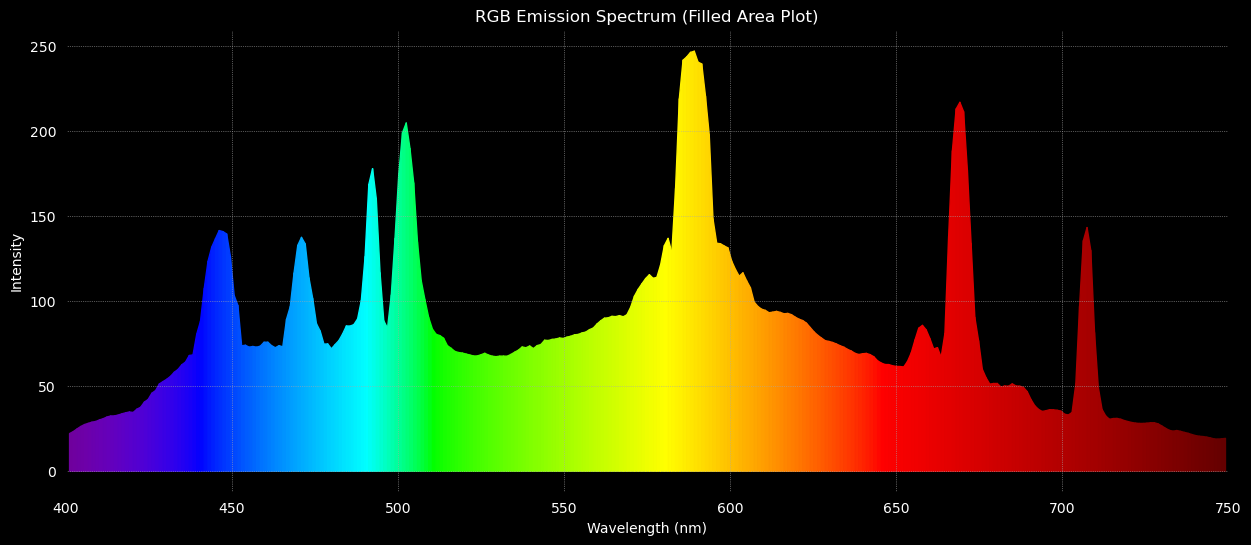

In [39]:
mode = 'dark'
reverse_x = False
# Create a colormap from the generated RGB colors
# Need to normalize the colors to be from 0 to 1 for the colormap to work correctly with x_normalized
normalized_colors = [(c[0], c[1], c[2]) for c in colors]

# Create a custom colormap from the list of RGB colors
cmap = LinearSegmentedColormap.from_list("spectrum_cmap", normalized_colors, N=len(x))

# Plotting
fig, ax = plt.subplots(figsize=(15, 6))

# Create a normalized version of x for the colormap mapping
x_normalized = (x - x.min()) / (x.max() - x.min())

# Fill the area under the curve with the custom colormap
for i in range(len(x) - 1):
    ax.fill_between(x[i:i+2], y[i:i+2], color=cmap(x_normalized[i]))

axis_labels()
ax.set_title('RGB Emission Spectrum (Filled Area Plot)', color = 'white')
plt.show()